# Groundwater age and reverse-GWT capture zones

## Overview

This notebook follows groundwater through the IISG model in two connected ways.

The first part estimates **groundwater age**: how long water has been moving through the modeled aquifer system. Age is useful because it gives the flow model a sense of time. Young groundwater usually points to quicker movement or more direct connection to recharge, boundaries, or nearby stresses. Older groundwater usually points to longer flow paths, slower movement, deeper parts of the system, or areas that are more isolated from recent recharge.

The second part turns the question around. Instead of asking where water goes, the **reverse-GWT capture-zone** run asks where water connected to selected pumping wells may have come from over 5, 10, and 15 years. A unit tracer signal is assigned at the pumping locations, and the transport model is run using a reversed flow field. The result is a relative connection-strength map: stronger signal means stronger modeled connection to the wells during the selected time window.

These maps are meant to support discussion. They are not perfect underground property lines. Groundwater moves through layers, gradients, boundaries, and pumping stresses; the mapped footprints are model-based summaries of that movement. The useful question is not only “where is the line?” but also “where is the model showing strong connection, where is the edge fuzzy, and what local knowledge should be compared with the result?”

### Main outputs

| Output | What it helps us see |
|---|---|
| Total groundwater age map | Where the model suggests groundwater is relatively young or old |
| Active-domain capture-zone map | The broader modeled footprint connected to the pumping wells |
| Local capture-zone map | A closer view of the capture-zone pattern near the area of interest |
| Flow-reversal check | Whether the transport-direction reversal is behaving the way the capture-zone method requires |


## 1. Imports

We start by loading the packages used for modeling, mapping, array calculations, and plotting. The important modeling package is `flopy`, which lets the notebook read, modify, write, and run MODFLOW 6 simulations. The other packages help with arrays, tables, file paths, and map display.

Keeping the imports together also makes the notebook easier to move between computers: if something is missing, it usually shows up here before the model workflow begins.


In [1]:
# Standard library
from pathlib import Path

# Scientific stack
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

# Geospatial / MODFLOW tools
import geopandas as gpd
import flopy


## 2. Paths and user settings

This cell defines the project folders, the MODFLOW 6 executable, and the county-boundary shapefile. These are the first settings to check when the notebook is moved to a new machine or a different project directory.

The workflow writes new model files into separate workspaces. The base model is treated as the starting point, not something to edit directly. That makes it easier to rerun the notebook, compare outputs, and avoid accidentally changing the reference model.


In [2]:
notebook_dir = Path.cwd()
home_dir = notebook_dir.parents[2]

sim_name = "mfsim"
base_model_workspace = Path(home_dir / "modflow_models" / "iisg_local_model")
age_model_workspace = Path(home_dir / "modflow_models" / "groundwater_age_model")

exe_name = Path(home_dir / "bin" / "mf6.exe")
county_shapefile = Path(home_dir / "data" / "background_shapefiles" / "counties_5070.shp")

print("Base model workspace:", base_model_workspace)
print("Groundwater age model workspace:", age_model_workspace)
print("MODFLOW 6 executable:", exe_name)
print("County shapefile:", county_shapefile)


Base model workspace: C:\Users\dbabrams\Documents\GitHub\modflow-state\modflow_models\iisg_local_model
Groundwater age model workspace: C:\Users\dbabrams\Documents\GitHub\modflow-state\modflow_models\groundwater_age_model
MODFLOW 6 executable: C:\Users\dbabrams\Documents\GitHub\modflow-state\bin\mf6.exe
County shapefile: C:\Users\dbabrams\Documents\GitHub\modflow-state\data\background_shapefiles\counties_5070.shp


## 3. Load the base groundwater-flow model

The base groundwater-flow model provides the grid, active cells, hydraulic properties, boundary conditions, pumping wells, and solved head field used throughout the notebook.

Once the simulation is loaded, we pull out the groundwater-flow model object. Later cells use that object to read model dimensions, layer information, packages, stresses, and saved output.


In [3]:
base_sim = flopy.mf6.MFSimulation.load(
    sim_name=sim_name,
    sim_ws=base_model_workspace,
    write_headers=False,
    exe_name=exe_name,
)

base_model_name = list(base_sim.model_names)[0]
base_gwf = base_sim.get_model(base_model_name)

print("Loaded base model:", base_model_name)


loading simulation...
  loading simulation name file...
  loading tdis package...
  loading model gwf6...
    loading package dis...
    loading package ic...
    loading package npf...
    loading package rch...
    loading package oc...
    loading package ghb...
    loading package sfr...
    loading package wel...
    loading package obs...
    loading package drn...
  loading solution package gwf-iisg...
Loaded base model: gwf-iisg


## 4. Create the groundwater-age working copy

The age simulation gets its own model workspace. This keeps the original base model available as the reference condition while giving the age workflow a safe place to write new files.

That copy-first pattern is useful for participatory modeling because it keeps the workflow traceable: the starting model stays intact, and each analysis step creates its own set of outputs.


In [4]:
base_sim.set_sim_path(age_model_workspace)
base_sim.write_simulation()

# Restore the base simulation path after writing the copy.
base_sim.set_sim_path(base_model_workspace)

age_sim = flopy.mf6.MFSimulation.load(
    sim_name=sim_name,
    sim_ws=age_model_workspace,
    write_headers=False,
    exe_name=exe_name,
)

age_model_name = list(age_sim.model_names)[0]
age_gwf = age_sim.get_model(age_model_name)

print("Loaded groundwater-age model:", age_model_name)
print("Age model workspace OK:", Path(age_gwf.model_ws) == age_model_workspace)


writing simulation...
  writing simulation name file...
  writing simulation tdis package...
  writing solution package gwf-iisg...
  writing model gwf-iisg...
    writing model name file...
    writing package dis...
    writing package ic...
    writing package npf...
    writing package rcha_0...
    writing package oc...
    writing package ghb_0...
    writing package sfr_obs...
    writing package sfr_0...
    writing package wel_obs...
    writing package wel_0...
    writing package obs_1...
    writing package drn_0...
loading simulation...
  loading simulation name file...
  loading tdis package...
  loading model gwf6...
    loading package dis...
    loading package ic...
    loading package npf...
    loading package rch...
    loading package oc...
    loading package ghb...
    loading package sfr...
    loading package wel...
    loading package obs...
    loading package drn...
  loading solution package gwf-iisg...
Loaded groundwater-age model: gwf-iisg
Age model work

## 5. Initialize groundwater-age starting heads

The age model needs an initial head field before transport can be solved. This cell uses the final saved heads from the base groundwater-flow model as the starting condition.

The goal is to start the age transport calculation from the same hydraulic condition represented by the base model, rather than inventing a new starting water-level surface.


In [5]:
base_headobj = base_gwf.output.head()
base_head_times = base_headobj.get_times()

if len(base_head_times) == 0:
    raise RuntimeError(
        "No base-model head output was found. Run the base model first, then rerun this cell."
    )

base_final_time = base_head_times[-1]
base_final_heads = np.array(base_headobj.get_data(totim=base_final_time), dtype=float)

age_start_heads = base_final_heads.copy()
current_start_heads = np.array(age_gwf.ic.strt.array, dtype=float)
idomain = np.array(age_gwf.dis.idomain.array)

bad_heads = (
    ~np.isfinite(age_start_heads)
    | (age_start_heads > 1.0e20)
    | (age_start_heads < -1.0e20)
    | (idomain <= 0)
)

age_start_heads[bad_heads] = current_start_heads[bad_heads]
age_gwf.ic.strt.set_data(age_start_heads)

print(f"Updated age-model initial heads from base model heads at time {base_final_time}.")
print(f"Initial head range: {np.nanmin(age_start_heads):.2f} to {np.nanmax(age_start_heads):.2f}")


Updated age-model initial heads from base model heads at time 1.0.
Initial head range: 29.38 to 258.61


## 6. Configure the groundwater-age run

Groundwater age is a long-time diagnostic. This run is set up to let the age field develop across the active model domain.

Later, the reverse-capture run uses a much shorter setup because that question focuses only on 5-, 10-, and 15-year connection windows. The two simulations are related, but they answer different time-scale questions.


In [6]:
# Keep this as the longer age-field run. The 16-step / 5-10-15 output
# request is handled in the reverse-capture GWT section below.

age_num_periods = 1
age_length_days = 365.25 * 500
age_time_steps = 25
age_timestep_mult = 1.05

age_time_dis = age_sim.get_package("tdis")
age_time_dis.nper = age_num_periods
age_time_dis.perioddata = [
    (age_length_days, age_time_steps, age_timestep_mult)
]

print(age_time_dis.perioddata.get_data())


[(182625., 25, 1.05)]


## 7. Build the groundwater-age transport model

Here the groundwater-flow model is paired with a groundwater-transport model. In this case, the transported quantity is **age**, not a chemical plume.

The idea follows the direct groundwater-age approach described by Goode (1996): age is treated as a transported quantity that increases as water moves through the model. The output is not a field measurement from a well sample; it is the model's estimate of how long water has been traveling under the simulated flow conditions.

This makes the age map useful as a regional context map. It helps identify where the modeled system behaves like a faster, younger flow system and where it behaves like a slower, older one.


In [7]:
age_gwt_name = f"{age_model_name}_gwt"

age_gwt = flopy.mf6.ModflowGwt(
    age_sim,
    modelname=age_gwt_name,
)

flopy.mf6.ModflowGwtdis(
    age_gwt,
    nlay=age_gwf.dis.nlay.array,
    nrow=age_gwf.dis.nrow.array,
    ncol=age_gwf.dis.ncol.array,
    delr=age_gwf.dis.delr.array,
    delc=age_gwf.dis.delc.array,
    top=age_gwf.dis.top.array,
    botm=age_gwf.dis.botm.array,
    idomain=age_gwf.dis.idomain.array,
    xorigin=age_gwf.modelgrid.xoffset,
    yorigin=age_gwf.modelgrid.yoffset,
    angrot=age_gwf.modelgrid.angrot,
)

print("\nGWF modelgrid extent:")
print(age_gwf.modelgrid.extent)

print("\nGWT modelgrid extent:")
print(age_gwt.modelgrid.extent)

# Initial age concentration = 0 everywhere.
flopy.mf6.ModflowGwtic(
    age_gwt,
    strt=0.0,
)

flopy.mf6.ModflowGwtadv(
    age_gwt,
    scheme="UPSTREAM",
)

# Porosity: use STO sy if available; otherwise use a constant fallback.
if age_gwf.get_package("sto") is not None and hasattr(age_gwf.sto, "sy"):
    porosity = np.array(age_gwf.sto.sy.array, dtype=float)
    porosity = np.where((porosity > 0) & np.isfinite(porosity), porosity, 0.15)
else:
    porosity = np.full(
        (
            age_gwf.modelgrid.nlay,
            age_gwf.modelgrid.nrow,
            age_gwf.modelgrid.ncol,
        ),
        0.15,
        dtype=float,
    )

# Groundwater-age trick:
# zero-order decay with negative decay produces age concentration over time.
age_decay_rate = -1.0  # age units per model day

flopy.mf6.ModflowGwtmst(
    age_gwt,
    porosity=porosity,
    zero_order_decay=True,
    decay=age_decay_rate,
    save_flows=False,
)

# Treat source water as zero-age water.
flopy.mf6.ModflowGwtssm(age_gwt)

# Save only the final total-age concentration field.
flopy.mf6.ModflowGwtoc(
    age_gwt,
    concentration_filerecord=f"{age_gwt_name}.ucn",
    saverecord=[
        ("CONCENTRATION", "LAST"),
    ],
)

# Add MVT if the GWF model has movers.
has_mvr = any("MVR" in package_name.upper() for package_name in age_gwf.get_package_list())

if has_mvr:
    flopy.mf6.ModflowGwtmvt(
        age_gwt,
        save_flows=True,
    )

age_ims = flopy.mf6.ModflowIms(
    age_sim,
    filename=f"{age_gwt.name}.ims",
    print_option="summary",
    complexity="simple",
    outer_maximum=100,
    inner_maximum=50,
    outer_dvclose=1.0e-2,
    inner_dvclose=1.0e-2,
    linear_acceleration="bicgstab",
)

age_sim.register_ims_package(
    age_ims,
    model_list=[f"{age_gwt.name}"],
)

flopy.mf6.ModflowGwfgwt(
    age_sim,
    exgtype="GWF6-GWT6",
    exgmnamea=age_gwf.name,
    exgmnameb=age_gwt.name,
)

print(f"Added GWT groundwater-age model: {age_gwt_name}")



GWF modelgrid extent:
(np.float64(638972.091), np.float64(752772.091), np.float64(2028133.96), np.float64(2197533.96))

GWT modelgrid extent:
(np.float64(638972.091), np.float64(752772.091), np.float64(2028133.96), np.float64(2197533.96))
Added GWT groundwater-age model: gwf-iisg_gwt


## 8. Run the groundwater-age model

This cell writes the updated simulation files and runs MODFLOW 6.

A successful run produces the transport output used in the total-age map. If the run fails, the MODFLOW listing file is usually the first place to check for convergence issues or package-input problems.


In [8]:
age_sim.write_simulation()

success, buff = age_sim.run_simulation()

if success:
    print("\n-- Groundwater age simulation completed successfully --\n")
else:
    raise RuntimeError("Groundwater age simulation failed. Check the listing file.")


writing simulation...
  writing simulation name file...
  writing simulation tdis package...
  writing solution package gwf-iisg...
  writing solution package ims_0...
  writing package mfsim.gwfgwt...
  writing model gwf-iisg...
    writing model name file...
    writing package dis...
    writing package ic...
    writing package npf...
    writing package rcha_0...
    writing package oc...
    writing package ghb_0...
    writing package sfr_obs...
    writing package sfr_0...
    writing package wel_obs...
    writing package wel_0...
    writing package obs_1...
    writing package drn_0...
  writing model gwf-iisg_gwt...
    writing model name file...
    writing package dis...
    writing package ic...
    writing package adv...
    writing package mst...
    writing package ssm...
    writing package oc...
FloPy is using the following executable to run the model: ..\..\bin\mf6.exe
                                   MODFLOW 6
                U.S. GEOLOGICAL SURVEY MODULAR HYDRO

## 9. Plot total groundwater age

The total-age map shows the final simulated groundwater age for the selected model layer. The plot is cropped to the active model domain so the figure focuses on the modeled aquifer system rather than the inactive rectangular grid around it.

Read this map as a pattern map. Older areas generally suggest longer flow paths, slower movement, or weaker connection to recent recharge. Younger areas generally suggest faster movement or stronger connection to recent recharge, boundaries, or stresses. The map is more useful for comparing regions than for treating any single cell as an exact field-measured age.


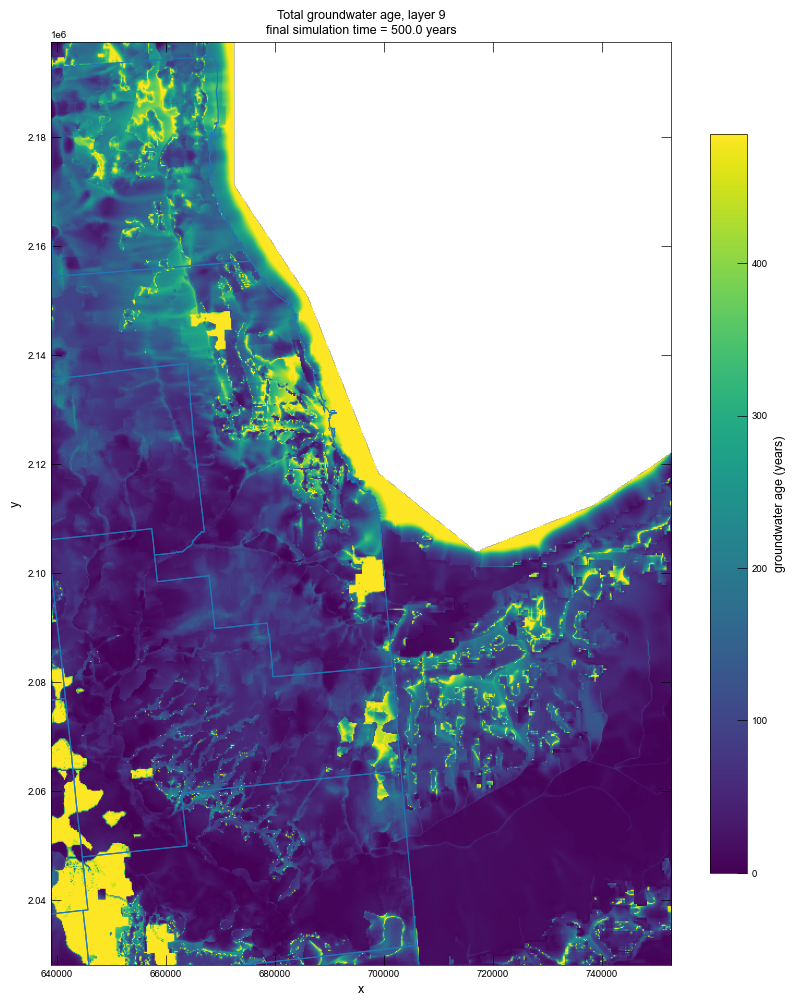

Plotted total groundwater age for active-domain extent.
Rows plotted: 0 to 846
Cols plotted: 0 to 568


In [9]:
# This keeps the whole active model domain visible while trimming the large
# inactive/blank grid area around it.

age_plot_layer = 8  # zero-based; 8 = model layer 9
plot_age_in_years = True
age_domain_pad_cells = 5

ucn = age_gwt.output.concentration()
times = ucn.get_times()

if len(times) == 0:
    raise RuntimeError("No groundwater-age concentration output was found.")

final_time = times[-1]
age_conc = np.array(ucn.get_data(totim=final_time), dtype=float)

age_map = age_conc[age_plot_layer].copy()
age_map[age_map > 1.0e20] = np.nan
age_map[age_map < -1.0e20] = np.nan

idomain = np.array(age_gwf.dis.idomain.array)
age_map = np.where(idomain[age_plot_layer] > 0, age_map, np.nan)

if plot_age_in_years:
    age_map = age_map / 365.25
    age_units = "years"
else:
    age_units = "days"

active_any_layer = np.any(idomain > 0, axis=0)
active_rows, active_cols = np.where(active_any_layer)

if active_rows.size == 0 or active_cols.size == 0:
    raise RuntimeError("No active cells found in idomain.")

row_start = max(int(active_rows.min()) - age_domain_pad_cells, 0)
row_end = min(int(active_rows.max()) + age_domain_pad_cells + 1, age_map.shape[0])
col_start = max(int(active_cols.min()) - age_domain_pad_cells, 0)
col_end = min(int(active_cols.max()) + age_domain_pad_cells + 1, age_map.shape[1])

age_map_zoom = age_map[row_start:row_end, col_start:col_end]

xcenters = age_gwf.modelgrid.xcellcenters
ycenters = age_gwf.modelgrid.ycellcenters

x_zoom = xcenters[row_start:row_end, col_start:col_end]
y_zoom = ycenters[row_start:row_end, col_start:col_end]

dx = np.nanmedian(np.abs(np.diff(xcenters, axis=1)))
dy = np.nanmedian(np.abs(np.diff(ycenters, axis=0)))

if not np.isfinite(dx):
    dx = 0.0
if not np.isfinite(dy):
    dy = 0.0

x_min = np.nanmin(x_zoom) - dx / 2
x_max = np.nanmax(x_zoom) + dx / 2
y_min = np.nanmin(y_zoom) - dy / 2
y_max = np.nanmax(y_zoom) + dy / 2

valid_age = age_map_zoom[np.isfinite(age_map_zoom)]

if valid_age.size > 0:
    vmin = 0.0
    vmax = np.nanpercentile(valid_age, 95)
else:
    vmin = 0.0
    vmax = 1.0

counties = gpd.read_file(county_shapefile)

try:
    model_crs = age_gwf.modelgrid.crs
except Exception:
    model_crs = None

if model_crs is not None and counties.crs is not None and counties.crs != model_crs:
    counties = counties.to_crs(model_crs)

counties_plot = counties.cx[x_min:x_max, y_min:y_max]

with flopy.plot.styles.USGSMap():
    fig, ax = plt.subplots(figsize=(10, 12))
    ax.set_aspect("equal")

    im = ax.imshow(
        np.ma.masked_invalid(age_map_zoom),
        origin="upper",
        extent=[x_min, x_max, y_min, y_max],
        vmin=vmin,
        vmax=vmax,
    )

    if len(counties_plot) > 0:
        counties_plot.boundary.plot(ax=ax, linewidth=0.8)

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_title(
        f"Total groundwater age, layer {age_plot_layer + 1}\n"
        f"final simulation time = {final_time / 365.25:.1f} years"
    )
    ax.set_xlabel("x")
    ax.set_ylabel("y")

    cbar = plt.colorbar(im, ax=ax, shrink=0.8)
    cbar.set_label(f"groundwater age ({age_units})")

    plt.show()

print("Plotted total groundwater age for active-domain extent.")
print(f"Rows plotted: {row_start} to {row_end - 1}")
print(f"Cols plotted: {col_start} to {col_end - 1}")


## 10. Reverse-capture setup

The reverse-capture analysis asks:

> If groundwater reaches these pumping wells, where does the model suggest that water may have come from during the previous 5, 10, and 15 years?

To answer that, the notebook runs a short reverse-transport experiment. A unit tracer signal is assigned at the pumping wells, the flow information is reversed for transport, and the GWT model tracks the signal backward through the modeled system. The model runs for 16 one-year time steps, but concentration output is saved only at 5, 10, and 15 years.

The main capture-zone threshold is set here. In this notebook, `C > 0.05` means a map cell is included where at least 5 percent of the unit reverse-tracer signal appears in any active layer below that row and column. Very tiny nonzero values are not used as the main footprint because transport models can produce trace signal through numerical spreading, grid resolution, time stepping, and solver behavior.


In [10]:
reverse_forward_workspace = Path(home_dir / "modflow_models" / "reverse_capture_forward_flow")
reverse_gwt_workspace = Path(home_dir / "modflow_models" / "reverse_capture_gwt_test")

reverse_lookback_years = 16.0
reverse_lookback_days = 365.25 * reverse_lookback_years
reverse_nsteps = 16
reverse_tsmult = 1.0

# Save/report reverse-GWT concentration only at these years/steps.
reverse_output_years = [5.0, 10.0, 25.0]
reverse_output_steps = [5, 10, 25]

# Main capture-zone threshold.
# A cell is mapped when the reverse-tracer concentration exceeds 5%
# of the unit signal assigned at the pumping well boundary.
# The diagnostic section below compares this value with lower thresholds.
capture_concentration_threshold = 0.05

# Auto-pick the first WEL package and all extracting wells with q < 0.
# Override these only if you want a narrower well set.
reverse_wel_package_name = None
reverse_wel_bndnos = None

# Local capture-zone map window.
# These are model coordinates; adjust here for a different local view.
local_capture_x_min = 680000.0
local_capture_x_max = 700000.0
local_capture_y_min = 2.08e6
local_capture_y_max = 2.10e6

active_domain_pad_cells = 5

run_reverse_forward_flow = True
run_reverse_gwt = True

if reverse_tsmult != 1.0:
    raise ValueError("The 5/10/15-year output-step logic assumes reverse_tsmult = 1.0.")

if reverse_nsteps != int(reverse_lookback_years):
    raise ValueError(
        "This notebook assumes one reverse-GWT time step per year. "
        "Set reverse_nsteps equal to reverse_lookback_years."
    )

print("Reverse forward-flow workspace:", reverse_forward_workspace)
print("Reverse GWT workspace:", reverse_gwt_workspace)
print("Reverse lookback years:", reverse_lookback_years)
print("Reverse GWT output years:", reverse_output_years)
print("Reverse GWT output steps:", reverse_output_steps)


Reverse forward-flow workspace: C:\Users\dbabrams\Documents\GitHub\modflow-state\modflow_models\reverse_capture_forward_flow
Reverse GWT workspace: C:\Users\dbabrams\Documents\GitHub\modflow-state\modflow_models\reverse_capture_gwt_test
Reverse lookback years: 16.0
Reverse GWT output years: [5.0, 10.0, 25.0]
Reverse GWT output steps: [5, 10, 25]


## 11. Reverse-capture helper functions

The reverse-capture workflow has a few repeated tasks: finding pumping wells, writing the reverse-source file, and setting up map windows.

The helper functions keep those details in one place so the rest of the notebook reads more like the modeling sequence: create forward-flow files, reverse the flow information, run reverse transport, and map the resulting connection signal.


In [11]:
def first_package(model, package_type):
    """Return the first package of a given MODFLOW 6 package type."""
    package_type = package_type.lower()
    for pkg in model.packagelist:
        if str(getattr(pkg, "package_type", "")).lower() == package_type:
            return pkg
    raise RuntimeError(f"No {package_type.upper()} package found.")


def package_name(pkg):
    """Return the FloPy package name as a plain string."""
    name = getattr(pkg, "package_name", None)
    if name is None:
        name = getattr(pkg, "pname", None)
    if hasattr(name, "array"):
        name = name.array
    if isinstance(name, (list, tuple, np.ndarray)):
        name = name[0]
    return str(name)


def final_heads_from_base(source_gwf, target_gwf):
    """Use the final base-model heads as starting heads for a copied model."""
    hds = source_gwf.output.head()
    final_time = hds.get_times()[-1]
    heads = np.array(hds.get_data(totim=final_time), dtype=float)

    idomain = np.array(target_gwf.dis.idomain.array)
    current = np.array(target_gwf.ic.strt.array, dtype=float)

    bad = (~np.isfinite(heads)) | (np.abs(heads) > 1.0e20) | (idomain <= 0)
    heads[bad] = current[bad]
    return heads, final_time


def choose_pumping_wells(gwf, kper=0):
    """Use all extracting wells in the first WEL package as reverse-tracer sources."""
    wel = first_package(gwf, "wel")
    data = wel.stress_period_data.get_data(key=kper)
    q = np.asarray(data["q"], dtype=float)

    bndnos = list(np.where(q < 0.0)[0] + 1)  # SPC6 boundary numbers are 1-based.
    maxbound = int(np.asarray(wel.maxbound.array).item())

    return wel, package_name(wel), bndnos, maxbound


def write_spc6_file(spc_path, bndnos, concentration, maxbound):
    """Write the SPC6 file that assigns reverse-tracer concentration to selected wells."""
    spc_path = Path(spc_path)
    spc_path.parent.mkdir(parents=True, exist_ok=True)

    with open(spc_path, "w") as f:
        f.write("BEGIN OPTIONS\n  PRINT_INPUT\nEND OPTIONS\n\n")
        f.write(f"BEGIN DIMENSIONS\n  MAXBOUND {maxbound}\nEND DIMENSIONS\n\n")
        f.write("BEGIN PERIOD 1\n")
        for bndno in bndnos:
            f.write(f"  {int(bndno)} CONCENTRATION {float(concentration):.16g}\n")
        f.write("END PERIOD\n")

    return spc_path


def turn_on_flow_output(gwf):
    """Save the flow terms needed by the reverse transport model."""
    for pkg in gwf.packagelist:
        if hasattr(pkg, "save_flows"):
            try:
                pkg.save_flows.set_data(True)
            except Exception:
                pass

    gwf.npf.save_flows.set_data(True)
    gwf.npf.save_specific_discharge.set_data(True)
    gwf.npf.save_saturation.set_data(True)


## 12. Create the forward-flow files that will be reversed

The reverse-transport model needs saved forward-flow output before that output can be reversed. This cell creates a short forward groundwater-flow run and saves the head and budget files needed by the reverse-GWT calculation.

This is not a new management scenario. It is a supporting run that produces the binary files used to build the reverse-capture experiment.


In [ ]:
reverse_forward_workspace.mkdir(parents=True, exist_ok=True)

# Write a copy of the base model to the reverse-forward workspace.
base_sim.set_sim_path(reverse_forward_workspace)
base_sim.write_simulation()
base_sim.set_sim_path(base_model_workspace)

reverse_forward_sim = flopy.mf6.MFSimulation.load(
    sim_name=sim_name,
    sim_ws=reverse_forward_workspace,
    write_headers=False,
    exe_name=exe_name,
)

reverse_forward_model_name = list(reverse_forward_sim.model_names)[0]
reverse_forward_gwf = reverse_forward_sim.get_model(reverse_forward_model_name)

reverse_start_heads, reverse_base_final_time = final_heads_from_base(base_gwf, reverse_forward_gwf)
reverse_forward_gwf.ic.strt.set_data(reverse_start_heads)

reverse_forward_sim.tdis.nper = 1
reverse_forward_sim.tdis.perioddata = [(reverse_lookback_days, reverse_nsteps, reverse_tsmult)]

if reverse_forward_gwf.get_package("sto") is not None:
    reverse_forward_gwf.sto.steady_state.set_data({0: True})
    reverse_forward_gwf.sto.transient.set_data({0: False})

reverse_forward_head_file = reverse_forward_workspace / f"{reverse_forward_gwf.name}.hds"
reverse_forward_budget_file = reverse_forward_workspace / f"{reverse_forward_gwf.name}.cbc"

reverse_forward_gwf.oc.head_filerecord.set_data(reverse_forward_head_file.name)
reverse_forward_gwf.oc.budget_filerecord.set_data(reverse_forward_budget_file.name)
reverse_forward_gwf.oc.saverecord.set_data({0: [("HEAD", "ALL"), ("BUDGET", "ALL")]})
reverse_forward_gwf.oc.printrecord.set_data({0: [("BUDGET", "LAST")]})

turn_on_flow_output(reverse_forward_gwf)

reverse_forward_sim.write_simulation()

if run_reverse_forward_flow:
    success, buff = reverse_forward_sim.run_simulation(silent=False, report=True)
    if not success:
        raise RuntimeError("Forward-flow run for reverse capture failed.")

print("Forward head file:", reverse_forward_head_file)
print("Forward budget file:", reverse_forward_budget_file)


writing simulation...
  writing simulation name file...
  writing simulation tdis package...
  writing solution package gwf-iisg...
  writing model gwf-iisg...
    writing model name file...
    writing package dis...


## 13. Select pumping wells and write the reverse-source file

The model's WEL package identifies pumping boundaries. This cell selects the extracting wells that will act as reverse-tracer source locations.

For the reverse-capture run, the wells are assigned a unit concentration in the SPC6 source file. That does not mean the wells contain a real contaminant. It is a modeling device: the unit signal gives the transport model something to trace backward through the flow system.


In [ ]:
reverse_wel_pkg, reverse_wel_pname, reverse_wel_bndnos, reverse_wel_maxbound = choose_pumping_wells(
    reverse_forward_gwf,
    kper=0,
)

reverse_spc_file = reverse_gwt_workspace / f"{reverse_wel_pname}.spc6"
write_spc6_file(
    spc_path=reverse_spc_file,
    bndnos=reverse_wel_bndnos,
    concentration=reverse_source_concentration,
    maxbound=reverse_wel_maxbound,
)

print("Reverse-source WEL package:", reverse_wel_pname)
print("Number of pumping wells used as reverse sources:", len(reverse_wel_bndnos))
print("SPC6 file:", reverse_spc_file)


## 14. Reverse the saved head and budget files

The forward-flow run produced the head and cell-by-cell budget files needed for transport. This cell uses FloPy's binary-file utilities to reverse those files for the backward transport calculation.

The budget file is the key piece for capture-zone mapping because it contains the intercell flow information used by GWT. Reversing that flow information lets the tracer signal move backward through the modeled connections instead of forward with groundwater flow.


In [ ]:
import flopy.utils.binaryfile as bf

reverse_head_file = reverse_gwt_workspace / f"{reverse_forward_gwf.name}_reverse.hds"
reverse_budget_file = reverse_gwt_workspace / f"{reverse_forward_gwf.name}_reverse.cbc"

reverse_gwt_workspace.mkdir(parents=True, exist_ok=True)

headobj = bf.HeadFile(str(reverse_forward_head_file), tdis=reverse_forward_sim.tdis)
headobj.reverse(filename=str(reverse_head_file))

cbb = bf.CellBudgetFile(str(reverse_forward_budget_file), tdis=reverse_forward_sim.tdis)
cbb.reverse(filename=str(reverse_budget_file))

print("Reversed head file:", reverse_head_file)
print("Reversed budget file:", reverse_budget_file)


## 15. Build and run the reverse transport model

This cell builds a GWT-only model connected to the reversed flow information. The model starts with a unit tracer signal at the selected pumping wells and moves that signal backward through the modeled flow field.

The run uses 16 one-year transport steps, but it saves concentration output only at years 5, 10, and 15. Those three saved times become the capture-zone maps used in the walkthrough.


In [ ]:
reverse_gwt_name = "rvcap_gwt"  # MF6 MODELNAME must be <= 16 characters

reverse_gwt_sim = flopy.mf6.MFSimulation(
    sim_name="reverse_capture_gwt_sim",
    sim_ws=reverse_gwt_workspace,
    exe_name=exe_name,
)

flopy.mf6.ModflowTdis(
    reverse_gwt_sim,
    time_units="DAYS",
    nper=1,
    perioddata=[(reverse_lookback_days, reverse_nsteps, reverse_tsmult)],
)

reverse_gwt = flopy.mf6.ModflowGwt(
    reverse_gwt_sim,
    modelname=reverse_gwt_name,
    save_flows=True,
)

flopy.mf6.ModflowGwtdis(
    reverse_gwt,
    nlay=reverse_forward_gwf.dis.nlay.array,
    nrow=reverse_forward_gwf.dis.nrow.array,
    ncol=reverse_forward_gwf.dis.ncol.array,
    delr=reverse_forward_gwf.dis.delr.array,
    delc=reverse_forward_gwf.dis.delc.array,
    top=reverse_forward_gwf.dis.top.array,
    botm=reverse_forward_gwf.dis.botm.array,
    idomain=reverse_forward_gwf.dis.idomain.array,
    xorigin=reverse_forward_gwf.modelgrid.xoffset,
    yorigin=reverse_forward_gwf.modelgrid.yoffset,
    angrot=reverse_forward_gwf.modelgrid.angrot,
)

flopy.mf6.ModflowGwtic(
    reverse_gwt,
    strt=0.0,
)

flopy.mf6.ModflowGwtadv(
    reverse_gwt,
    scheme="UPSTREAM",
)

if reverse_forward_gwf.get_package("sto") is not None and hasattr(reverse_forward_gwf.sto, "sy"):
    reverse_porosity = np.array(reverse_forward_gwf.sto.sy.array, dtype=float)
    reverse_porosity = np.where((reverse_porosity > 0) & np.isfinite(reverse_porosity), reverse_porosity, 0.15)
else:
    reverse_porosity = np.full(
        (
            reverse_forward_gwf.modelgrid.nlay,
            reverse_forward_gwf.modelgrid.nrow,
            reverse_forward_gwf.modelgrid.ncol,
        ),
        0.15,
        dtype=float,
    )

flopy.mf6.ModflowGwtmst(
    reverse_gwt,
    porosity=reverse_porosity,
    save_flows=True,
)

flopy.mf6.ModflowGwtfmi(
    reverse_gwt,
    save_flows=True,
    packagedata=[
        ("GWFHEAD", str(reverse_head_file)),
        ("GWFBUDGET", str(reverse_budget_file)),
    ],
)

flopy.mf6.ModflowGwtssm(
    reverse_gwt,
    print_flows=True,
    save_flows=True,
    fileinput=[
        (reverse_wel_pname, str(reverse_spc_file)),
    ],
)

# Run 16 one-year steps, but save/report concentration only at 5, 10, and 15 years.
flopy.mf6.ModflowGwtoc(
    reverse_gwt,
    concentration_filerecord=f"{reverse_gwt_name}.ucn",
    saverecord=[
        ("CONCENTRATION", "STEPS", *reverse_output_steps),
    ],
    printrecord=[
        ("CONCENTRATION", "STEPS", *reverse_output_steps),
    ],
)

reverse_gwt_ims = flopy.mf6.ModflowIms(
    reverse_gwt_sim,
    filename=f"{reverse_gwt_name}.ims",
    print_option="summary",
    complexity="simple",
    outer_maximum=100,
    inner_maximum=100,
    outer_dvclose=1.0e-6,
    inner_dvclose=1.0e-6,
    linear_acceleration="bicgstab",
)

reverse_gwt_sim.register_ims_package(
    reverse_gwt_ims,
    model_list=[reverse_gwt.name],
)

reverse_gwt_sim.write_simulation()

if run_reverse_gwt:
    success, buff = reverse_gwt_sim.run_simulation(silent=False, report=True)
    if not success:
        raise RuntimeError("Reverse GWT run failed. Check the reverse GWT listing file.")
    print("\n-- Reverse GWT simulation completed --\n")
else:
    print("run_reverse_gwt = False, so the reverse GWT simulation was written but not executed.")

reverse_ucn = reverse_gwt.output.concentration()
print("Saved reverse-GWT concentration output times, in years:")
print([t / 365.25 for t in reverse_ucn.get_times()])


## 16. Plot reverse-capture zones

The capture-zone maps convert the reverse-tracer concentration field into nested 5-, 10-, and 15-year footprints. A row and column appears on the plan-view map when any active model layer beneath it exceeds the selected threshold.

| Zone | Interpretation |
|---|---|
| 5-year zone | Stronger modeled connection within 5 years |
| 10-year zone | Additional area connected within 10 years |
| 15-year zone | Broader footprint connected within 15 years |

Because the map collapses all layers into one plan view, a colored surface cell does not necessarily mean the shallowest layer is the source. It means at least one active aquifer layer under that row and column crossed the threshold. That makes the map useful for regional screening and discussion, while still reminding us that the vertical structure of the aquifer matters.

The active-domain map shows the full modeled footprint. The local map zooms in so the pattern can be discussed at a scale closer to the places people recognize.


In [ ]:
def model_counties(gwf):
    counties = gpd.read_file(county_shapefile)
    model_crs = gwf.modelgrid.crs
    if model_crs is not None and counties.crs is not None and counties.crs != model_crs:
        counties = counties.to_crs(model_crs)
    return counties


def active_window(idomain, pad_cells=5):
    active = np.any(idomain > 0, axis=0)
    rows, cols = np.where(active)
    return (
        max(rows.min() - pad_cells, 0),
        min(rows.max() + pad_cells + 1, active.shape[0]),
        max(cols.min() - pad_cells, 0),
        min(cols.max() + pad_cells + 1, active.shape[1]),
    )


def xy_window(gwf, idomain, x_min, x_max, y_min, y_max):
    x = gwf.modelgrid.xcellcenters
    y = gwf.modelgrid.ycellcenters
    active = np.any(idomain > 0, axis=0)
    inside = active & (x >= x_min) & (x <= x_max) & (y >= y_min) & (y <= y_max)
    rows, cols = np.where(inside)
    return rows.min(), rows.max() + 1, cols.min(), cols.max() + 1


def window_extent(gwf, row0, row1, col0, col1):
    x = gwf.modelgrid.xcellcenters
    y = gwf.modelgrid.ycellcenters
    dx = np.nanmedian(np.abs(np.diff(x, axis=1)))
    dy = np.nanmedian(np.abs(np.diff(y, axis=0)))
    return (
        np.nanmin(x[row0:row1, col0:col1]) - dx / 2,
        np.nanmax(x[row0:row1, col0:col1]) + dx / 2,
        np.nanmin(y[row0:row1, col0:col1]) - dy / 2,
        np.nanmax(y[row0:row1, col0:col1]) + dy / 2,
    )


def concentration_at_year(ucn, year):
    times = np.array(ucn.get_times(), dtype=float)
    target = year * 365.25
    t = times[np.argmin(np.abs(times - target))]
    return np.array(ucn.get_data(totim=t), dtype=float), t


def capture_masks(reverse_gwt, gwf, years, threshold):
    ucn = reverse_gwt.output.concentration()
    idomain = np.array(gwf.dis.idomain.array)
    masks = {}
    times = {}

    for year in years:
        conc, t = concentration_at_year(ucn, year)
        masks[year] = np.any((idomain > 0) & np.isfinite(conc) & (conc > threshold), axis=0)
        times[year] = t

    return masks, times


def plot_capture_zones(mode="active_domain", title="Reverse-GWT capture zones"):
    idomain = np.array(reverse_forward_gwf.dis.idomain.array)
    masks, times = capture_masks(
        reverse_gwt,
        reverse_forward_gwf,
        reverse_output_years,
        capture_concentration_threshold,
    )

    if mode == "active_domain":
        row0, row1, col0, col1 = active_window(idomain, active_domain_pad_cells)
    else:
        row0, row1, col0, col1 = xy_window(
            reverse_forward_gwf,
            idomain,
            local_capture_x_min,
            local_capture_x_max,
            local_capture_y_min,
            local_capture_y_max,
        )

    xmin, xmax, ymin, ymax = window_extent(reverse_forward_gwf, row0, row1, col0, col1)
    counties = model_counties(reverse_forward_gwf).cx[xmin:xmax, ymin:ymax]

    colors = {5.0: "tab:red", 10.0: "tab:orange", 15.0: "tab:blue"}
    fig, ax = plt.subplots(figsize=(11, 10))
    ax.set_aspect("equal")

    active = np.any(idomain > 0, axis=0)[row0:row1, col0:col1]
    ax.imshow(
        np.where(active, 1.0, np.nan),
        origin="upper",
        extent=[xmin, xmax, ymin, ymax],
        cmap=ListedColormap(["lightgray"]),
        alpha=0.25,
    )

    # Draw the largest time window first, then stack shorter travel times on top.
    for year in sorted(reverse_output_years, reverse=True):
        zone = masks[year][row0:row1, col0:col1]
        ax.imshow(
            np.where(zone, 1.0, np.nan),
            origin="upper",
            extent=[xmin, xmax, ymin, ymax],
            cmap=ListedColormap([colors[float(year)]]),
            alpha=0.65,
        )

    if len(counties) > 0:
        counties.boundary.plot(ax=ax, linewidth=0.8)

    handles = [
        Patch(facecolor=colors[float(year)], alpha=0.65, label=f"{year:g}-year zone")
        for year in sorted(reverse_output_years)
    ]
    ax.legend(handles=handles, loc="upper right")
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(f"{title}\nthreshold C > {capture_concentration_threshold:g}")
    plt.show()

    for year in sorted(reverse_output_years):
        print(f"{year:g}-year cells:", int(masks[year].sum()), f"(output = {times[year] / 365.25:.1f} years)")


plot_capture_zones(mode="active_domain", title="Capture zones, active-domain overview")
plot_capture_zones(mode="local", title="Capture zones, local map")


## 17. Check the flow reversal

The reverse-capture run depends on one important mechanical step: the transport model must use flow directions that are turned around from the forward groundwater-flow solution.

The head surface is not expected to flip. Heads still show the same modeled water-level pattern because they describe the hydraulic surface from the flow solution. What changes for the reverse-transport calculation is the direction of movement used by the tracer signal. In other words, the map can have similar head colors in both panels while the arrows point in opposite directions.

This figure checks that idea in two ways. The left panel shows the forward head field with forward flow arrows. The right panel shows the same head context with the reversed transport-direction arrows used to explain the reverse-GWT setup. The printed budget check compares the `FLOW-JA-FACE` terms in the forward and reversed budget files; values near `-1` indicate that the intercell budget terms used by GWT have been sign-reversed.

This is not a capture-zone result. It is a quality-control and explanation figure. It helps confirm that the reverse-capture maps are built from a reversed transport direction, not from a second forward-flow interpretation.


In [ ]:
from flopy.utils.postprocessing import get_specific_discharge

flow_check_layer = age_plot_layer
flow_check_map_mode = "active_domain"  # "active_domain" or "local"
flow_vector_stride = 12 if flow_check_map_mode == "active_domain" else 4
flow_head_contour_count = 10


def read_heads(head_file):
    hds = bf.HeadFile(str(head_file), tdis=reverse_forward_sim.tdis)
    time = hds.get_times()[-1]
    heads = np.array(hds.get_data(totim=time), dtype=float)
    return heads, time


def read_spdis(budget_file):
    cbb = bf.CellBudgetFile(str(budget_file), tdis=reverse_forward_sim.tdis)
    time = cbb.get_times()[-1]
    spdis = cbb.get_data(text="DATA-SPDIS", totim=time)[0]
    qx, qy, qz = get_specific_discharge(spdis, reverse_forward_gwf)
    return np.array(qx), np.array(qy), time


def flowja_values(budget_file):
    cbb = bf.CellBudgetFile(str(budget_file), tdis=reverse_forward_sim.tdis)
    time = cbb.get_times()[-1]
    return np.asarray(cbb.get_data(text="FLOW-JA-FACE", totim=time)[0], dtype=float)


forward_heads, forward_head_time = read_heads(reverse_forward_head_file)
reversed_heads, reversed_head_time = read_heads(reverse_head_file)
forward_qx, forward_qy, forward_budget_time = read_spdis(reverse_forward_budget_file)

# DATA-SPDIS in a reversed budget file can still look like the original vector field.
# The GWT transport calculation uses the reversed cell-by-cell budget flows.
# For this visual check, plot the reverse transport direction directly.
reversed_qx = -forward_qx
reversed_qy = -forward_qy

idomain = np.array(reverse_forward_gwf.dis.idomain.array)

if flow_check_map_mode == "active_domain":
    row0, row1, col0, col1 = active_window(idomain, active_domain_pad_cells)
else:
    row0, row1, col0, col1 = xy_window(
        reverse_forward_gwf,
        idomain,
        local_capture_x_min,
        local_capture_x_max,
        local_capture_y_min,
        local_capture_y_max,
    )

xmin, xmax, ymin, ymax = window_extent(reverse_forward_gwf, row0, row1, col0, col1)
counties = model_counties(reverse_forward_gwf).cx[xmin:xmax, ymin:ymax]

x = reverse_forward_gwf.modelgrid.xcellcenters[row0:row1, col0:col1]
y = reverse_forward_gwf.modelgrid.ycellcenters[row0:row1, col0:col1]
active = idomain[flow_check_layer, row0:row1, col0:col1] > 0

pairs = [
    ("Forward heads and flow", forward_heads, forward_qx, forward_qy),
    ("Forward heads with reversed transport direction", reversed_heads, reversed_qx, reversed_qy),
]

fig, axes = plt.subplots(1, 2, figsize=(16, 8), constrained_layout=True)

for ax, (title, heads, qx, qy) in zip(axes, pairs):
    h = np.where(active, heads[flow_check_layer, row0:row1, col0:col1], np.nan)
    qx_layer = np.where(active, qx[flow_check_layer, row0:row1, col0:col1], np.nan)
    qy_layer = np.where(active, qy[flow_check_layer, row0:row1, col0:col1], np.nan)

    im = ax.imshow(
        np.ma.masked_invalid(h),
        origin="upper",
        extent=[xmin, xmax, ymin, ymax],
    )

    cs = ax.contour(x, y, h, levels=flow_head_contour_count, linewidths=0.8)
    ax.clabel(cs, fontsize=7, inline=True)

    ax.quiver(
        x[::flow_vector_stride, ::flow_vector_stride],
        y[::flow_vector_stride, ::flow_vector_stride],
        qx_layer[::flow_vector_stride, ::flow_vector_stride],
        qy_layer[::flow_vector_stride, ::flow_vector_stride],
        pivot="middle",
    )

    if len(counties) > 0:
        counties.boundary.plot(ax=ax, linewidth=0.8)

    ax.set_title(title)
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_aspect("equal")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    fig.colorbar(im, ax=ax, shrink=0.75, label="head")

plt.show()

# Direct check on the budget terms GWT reads for intercell transport.
forward_flowja = flowja_values(reverse_forward_budget_file)
reversed_flowja = flowja_values(reverse_budget_file)
flowja_mask = np.isfinite(forward_flowja) & np.isfinite(reversed_flowja) & (np.abs(forward_flowja) > 0)

ratio = reversed_flowja[flowja_mask] / forward_flowja[flowja_mask]
relative_mismatch = np.nanmax(np.abs(forward_flowja[flowja_mask] + reversed_flowja[flowja_mask])) / np.nanmax(np.abs(forward_flowja[flowja_mask]))

print(f"Forward head time: {forward_head_time / 365.25:.2f} years")
print(f"Reversed head time: {reversed_head_time / 365.25:.2f} years")
print(f"Forward budget time: {forward_budget_time / 365.25:.2f} years")
print("Median reversed/FLOW-JA-FACE forward ratio:", np.nanmedian(ratio))
print("Maximum relative |forward + reversed| mismatch:", relative_mismatch)
print("Expected for a clean reversal: median ratio near -1 and mismatch near 0.")


## 18. Background and interpretation

This notebook uses two transport ideas together: direct groundwater-age simulation and reverse transport for capture-zone screening.

**Groundwater age** estimates how long water has been moving through the modeled aquifer system. It helps show where the model behaves like a younger, faster-connected flow system and where it behaves like an older, slower, or more isolated one. The age map is a model interpretation, not a direct measurement at every cell.

**Reverse capture** starts at the pumping wells and traces a unit signal backward through the modeled flow system. The resulting concentration is best read as relative connection strength. Higher values indicate stronger modeled connection to the selected pumping locations during the selected time window.

The concentration threshold matters because a transport solution fades outward. A very small nonzero value can cover a large area, especially when numerical dispersion, grid resolution, time stepping, and solver tolerances are involved. In threshold testing, `C > 0` was too broad to be useful as a main planning footprint. The `0.01` and `0.05` footprints were much more stable and told a similar spatial story. This notebook uses **`C > 0.05`** for the main maps so the displayed footprint emphasizes the stronger-signal part of the modeled connection.

This is different from a particle-tracking map, but not because particle tracking has no judgment calls. Particle tracking often looks crisper because the choices are hidden in particle release locations, particle density, porosity, and how pathlines are turned into a polygon. Reverse transport shows the fading signal directly, so the cutoff is named and can be tested.

### References

- Goode, D.J., 1996, Direct simulation of groundwater age, *Water Resources Research*, 32(2), 289–296.
- Neupauer, R.M., and Wilson, J.L., 2004, Numerical implementation of a backward probabilistic model of ground water contamination, *Ground Water*, 42(2), 175–189.
- Tosco, T., and Sethi, R., 2010, Comparison between backward probability and particle tracking methods for the delineation of well head protection areas, *Environmental Fluid Mechanics*, 10, 77–90.
- Zheng, C., and Wang, P.P., 1999, *MT3DMS: A modular three-dimensional multispecies transport model for simulation of advection, dispersion, and chemical reactions of contaminants in groundwater systems*.
- Bedekar, V., Morway, E.D., Langevin, C.D., and Tonkin, M., 2016, *MT3D-USGS version 1: A U.S. Geological Survey release of MT3DMS updated for use with MODFLOW*.


## 19. Reading the results together

The maps are most useful when they are read as a sequence rather than as separate products.

Start with the **groundwater-age map**. It gives regional context for the flow system: where the model suggests groundwater is younger, older, faster-connected, or slower-moving.

Then look at the **flow-reversal check**. This figure explains the mechanics of the reverse-capture setup. The head pattern provides familiar hydraulic context, while the arrows show the forward flow direction beside the reversed transport direction used for capture mapping.

Finally, read the **capture-zone maps**. The 5-year zone shows the strongest near-term modeled connection to the pumping wells. The 10- and 15-year zones show how that connected footprint expands as the travel-time window gets longer. The local map brings the same result into a smaller area where roads, boundaries, wells, and community questions can be discussed more directly.

The strongest conclusions are the patterns that survive across these views. The most useful questions often sit near the edges: places where the mapped footprint depends on threshold choice, layer structure, pumping assumptions, or local hydrogeologic knowledge. That is where the model becomes a shared object for discussion rather than just a finished picture.
